Acurácia: 0.8696491792726102
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1570
           1       0.87      0.87      0.87      1537

    accuracy                           0.87      3107
   macro avg       0.87      0.87      0.87      3107
weighted avg       0.87      0.87      0.87      3107

--- Importância SHAP das Features ---
                feature  importance_shap
0                     M         0.138619
8  pontuacao_anfipatica         0.087980
1                     K         0.082950
2                     C         0.064971
4                     D         0.047266
5                     P         0.037853
3                     R         0.037350
6                     G         0.030838
7                     L         0.020031


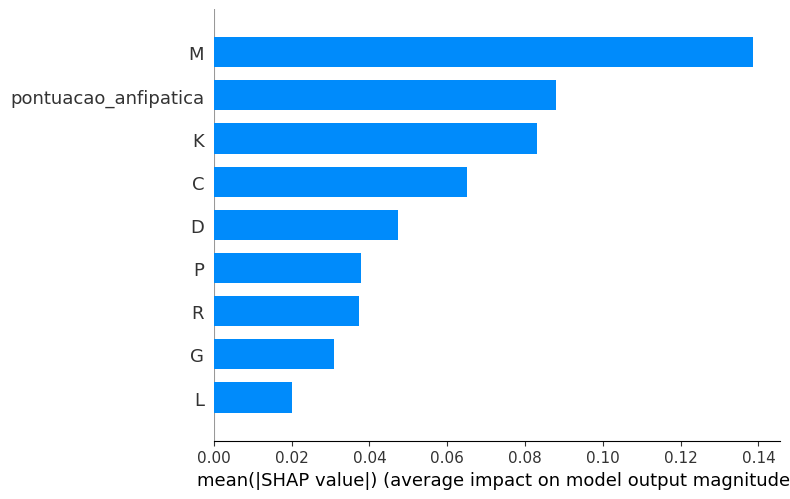

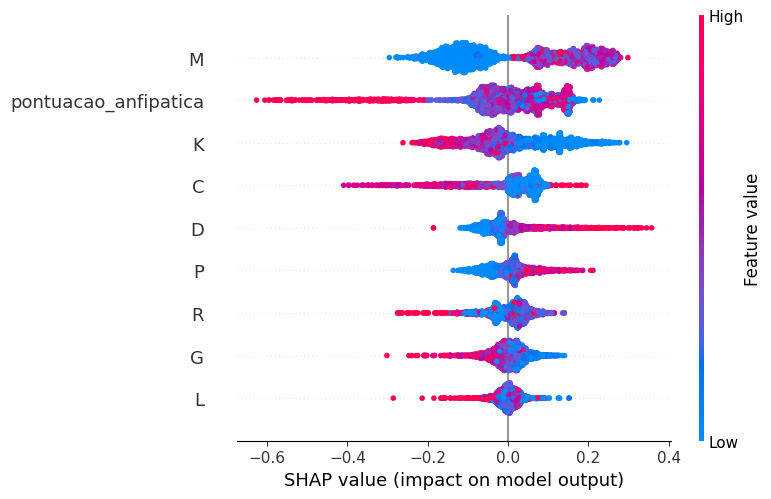

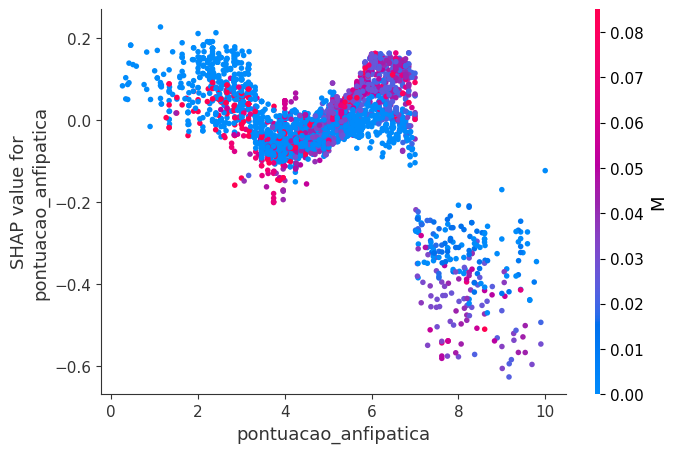

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import shap
import math

df = pd.read_csv("amp_dataset.csv", on_bad_lines='skip')

# Aminos Alfa-Helices: A, L, M, E, Q
#Aminos Beta-Folha: V, I, Y, F, W
# "Cotovelos": P, G

#Apolar: A, V, L, E, Q I, L, M, F, Y, W
#Polar: K, R, H, D, E, S, T, N, Q

#Exemplo Alfa-Hélice perfeita: AAAAAAA...
#Alfa-Helice anfipática: LKLKLKLK...
#Folha-Beta anfipática: VKVKVKVK...

apolar = {'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G'} 
polar = {'S', 'T', 'C', 'Y', 'N', 'Q', 'D', 'E', 'K', 'R', 'H'}

def calcular_pontuacao_anfipatica(sequencia):
    sequencia = sequencia.upper()

    pontuacao_total = 0.0
    length = len(sequencia)
    indices_apolares = [i for i, aminoacido in enumerate(sequencia) if aminoacido in apolar]
    
    if len(indices_apolares) < 2:
        return float(len(sequencia))
        
    diferenca = []
    
    for i in range(len(indices_apolares)-1): 
        if(i<len(indices_apolares)):
            diferenca.append(indices_apolares[i] - indices_apolares[i+1])

    pontuacao_total = (sum(diferenca)**2)/(length-1)
    return math.sqrt(pontuacao_total)
   
#amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
amino_acids = list("MKCRDPGL") # aplicando PCA

def aa_composition(seq):
    seq = seq.upper()
    length = len(seq)
    comp = {}
    for aa in amino_acids:
        comp[aa] = seq.count(aa) / length
    return comp
    

features_acc = df['sequence'].apply(aa_composition)
feature_anfipatico = df['sequence'].apply(calcular_pontuacao_anfipatica)
#feature_anf_feito = df['sequence'].apply(calcular_pontuacao_anfipatica_feito)


features_df = pd.DataFrame(features_acc.tolist(), index=df.index)

features_df['pontuacao_anfipatica'] = feature_anfipatico
#features_df['pontuacao_anf_feito'] = feature_anf_feito

features_df['label'] = df['class'].map({'AMP': 1, 'nonAMP': 0})

X = features_df.drop(columns=['label'])
y = features_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# treinar ============================================

model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Acurácia:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# scale = range(1,400,50)
# acuracia_model = []
# for i in scale:
#     model = RandomForestClassifier(n_estimators=i, random_state=42, class_weight="balanced")
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     acuracia_model.append(accuracy_score(y_test, y_pred))


#model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced") -  0.8984947896565033
#model = DecisionTreeClassifier(max_depth=10, random_state=42) - 0.8433037437282902
#model = KNeighborsClassifier(n_neighbors=4) -  0.8708992666923968

# Criar o explicador SHAP
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1] #(AMP = 1)
else:
    shap_values_class1 = shap_values
if shap_values_class1.ndim == 3:
    shap_values_class1 = shap_values_class1[:, :, 0]

    
feature_importance_shap = np.abs(shap_values_class1).mean(axis=0)

importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_shap': feature_importance_shap
}).sort_values('importance_shap', ascending=False)

print("--- Importância SHAP das Features ---")
print(importance_df)


shap.summary_plot(shap_values_class1, X_test, plot_type="bar")
shap.summary_plot(shap_values_class1, X_test)
shap.force_plot(explainer.expected_value[1], shap_values_class1[0,:], X_test.iloc[0,:])
shap.dependence_plot("pontuacao_anfipatica", shap_values_class1, X_test)

In [ ]:
#=============================================

# Definição dos conjuntos de aminoácidos (corrigidos)

#

def calcular_pontuacao_anfipatica_feito(sequencia):
    sequencia = sequencia.upper()
    if len(sequencia) < 3:
        return 0

    pontuacao_total = 0.0
    pesos = [0.3, 0.5, 0.3]
    
    padrao_ideal_1 = ['polar', 'apolar','polar']
    padrao_ideal_2 = ['apolar','polar', 'apolar']

    for i in range(len(sequencia) - 2):
        tripeptideo = sequencia[i : i+3]
        
        padrao_atual = []
        for aminoacido in tripeptideo:
            if aminoacido in apolar:
                padrao_atual.append('apolar')
            elif aminoacido in polar:
                padrao_atual.append('polar')
            else:
                padrao_atual.append('neutro')

        pontuacao_match_1 = 0
        pontuacao_match_2 = 0
        
        for j in range(3):
            if padrao_atual[j] == padrao_ideal_1[j]:
                pontuacao_match_1 += pesos[j]
            if padrao_atual[j] == padrao_ideal_2[j]:
                pontuacao_match_2 += pesos[j]
        
        # Adiciona a maior das duas pontuações à pontuação total
        pontuacao_total += max(pontuacao_match_1, pontuacao_match_2)

    # Normaliza a pontuação pelo número de tripeptídeos analisados
    numero_de_tripeptideos = len(sequencia) - 2
    pontuacao_final_normalizada = pontuacao_total / numero_de_tripeptideos
    
    return pontuacao_final_normalizada

# --- Exemplo de Uso ---
peptideo_anfipatico_ideal = "LKLKLKLKLK"  # Padrão alternado perfeito
peptideo_agrupado = "LLLLLKKKKK"   # Sem alternância
peptideo_aleatorio = "AGKPYEWQSFL"



#=============================================